# Family-fix `diag_results` comprehensive diagnostics

This notebook performs a comprehensive analysis of the saved **family-fix calibration-bank runs** in:

`C:\Users\yangy\26 spring\with reference\familyfix\diag_results`

Project rule for this notebook:

- The target is **pointwise deployed coverage near 0.95**
- We focus on the points that remain **undercovered in the final selected deployed double check**
- Overcoverage is **not** treated as the main issue here
- We want to understand the full chain:

\[
	ext{estimated coverage from pseudo-truth} \;	o\; 
	ext{true-hit behavior inside calibration bank} \;	o\;
	ext{true-hit behavior inside final deployed family}
\]

The notebook therefore separates three objects:

1. **Estimated coverage**: split-bootstrap pseudo-truth coverage used to choose `alpha_star(x)`
2. **Calibration true-hit coverage**: what would happen inside the *same calibration bootstrap bank* if we tested against the known simulation truth \(f_0\) instead of pseudo-truth
3. **Final deployed coverage**: full-data deployed family tested against \(f_0\)

This lets us decompose mismatch into:

- **pseudo-target bias**:
  \[
  	ext{calibration true-hit} - 	ext{estimated pseudo-hit}
  \]
- **deploy transfer gap**:
  \[
  	ext{final deployed coverage} - 	ext{calibration true-hit}
  \]
- **total gap**:
  \[
  	ext{final deployed coverage} - 	ext{estimated coverage}
  \]

In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 160

RESULTS_DIR = Path(r"C:\Users\yangy\26 spring\with reference\familyfix\diag_results")
OUTPUT_DIR = RESULTS_DIR / "comprehensive_diagnostics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR, OUTPUT_DIR

(WindowsPath('C:/Users/yangy/26 spring/with reference/familyfix/diag_results'),
 WindowsPath('C:/Users/yangy/26 spring/with reference/familyfix/diag_results/comprehensive_diagnostics'))

## 1. Load files and validate grids / shapes

In [2]:
DEPLOY_SELECTED_PATTERN = "deploy_final_rep*_J*.csv"
DEPLOY_BANK_PATTERN = "deploy_full_by_alpha_rep*_A*_J*.npz"
COVERAGE_PATTERN = "pointwise_coverage_rep*_A*_B*.csv"
ALPHA_STAR_PATTERN = "alpha_star_curve_rep*.csv"
PSEUDO_PATTERN = "pseudo_truth_rep*_A*_J*.npy"
CALIB_BANK_PATTERN = "calib_bootstrap_interval_bank_rep*_A*_B*_J*.npz"
META_PATTERN = "meta_rep*.json"

rep_regex = re.compile(r"rep(\d+)")

def parse_rep_id(path: Path) -> int:
    m = rep_regex.search(path.stem)
    if m is None:
        raise ValueError(f"Could not parse rep id from {path.name}")
    return int(m.group(1))

def load_optional_json(path: Path):
    if path is None or not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

deploy_selected_files = sorted(RESULTS_DIR.glob(DEPLOY_SELECTED_PATTERN), key=parse_rep_id)
deploy_bank_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(DEPLOY_BANK_PATTERN)}
coverage_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(COVERAGE_PATTERN)}
alpha_star_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(ALPHA_STAR_PATTERN)}
pseudo_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(PSEUDO_PATTERN)}
calib_bank_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(CALIB_BANK_PATTERN)}
meta_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(META_PATTERN)}

print(f"Found {len(deploy_selected_files)} selected deploy files")
print(f"Found {len(deploy_bank_files)} deploy alpha-bank files")
print(f"Found {len(coverage_files)} pointwise coverage files")
print(f"Found {len(alpha_star_files)} alpha-star files")
print(f"Found {len(pseudo_files)} pseudo-truth files")
print(f"Found {len(calib_bank_files)} calibration-bank files")
print(f"Found {len(meta_files)} meta files")

if len(deploy_selected_files) == 0:
    raise FileNotFoundError(f"No files matching {DEPLOY_SELECTED_PATTERN} were found in {RESULTS_DIR}")

required = {
    "deploy_bank": deploy_bank_files,
    "coverage": coverage_files,
    "alpha_star": alpha_star_files,
    "pseudo_truth": pseudo_files,
    "calib_bank": calib_bank_files,
    "meta": meta_files,
}
for name, mapping in required.items():
    missing = [parse_rep_id(p) for p in deploy_selected_files if parse_rep_id(p) not in mapping]
    if missing:
        raise FileNotFoundError(f"Missing {name} files for rep ids: {missing[:10]}")

Found 100 selected deploy files
Found 100 deploy alpha-bank files
Found 100 pointwise coverage files
Found 100 alpha-star files
Found 100 pseudo-truth files
Found 100 calibration-bank files
Found 100 meta files


In [3]:
records = []
x_ref = None
true_f_ref = None
ci_level = None
z_ci = None
alpha_vals_ref = None
B_ref = None

for deploy_path in deploy_selected_files:
    rep_id = parse_rep_id(deploy_path)
    deploy_df = pd.read_csv(deploy_path).sort_values("x").reset_index(drop=True)

    if x_ref is None:
        x_ref = deploy_df["x"].to_numpy(dtype=float)
        true_f_ref = deploy_df["true_f"].to_numpy(dtype=float)
    else:
        if not np.allclose(x_ref, deploy_df["x"].to_numpy(dtype=float)):
            raise ValueError(f"x-grid mismatch in selected deploy file for rep {rep_id}")
        if not np.allclose(true_f_ref, deploy_df["true_f"].to_numpy(dtype=float)):
            raise ValueError(f"true_f mismatch in selected deploy file for rep {rep_id}")

    meta = load_optional_json(meta_files.get(rep_id))
    if meta is not None and ci_level is None:
        ci_level = float(meta.get("ci_level", np.nan))
        z_ci = float(meta.get("z_ci", np.nan))

    alpha_df = pd.read_csv(alpha_star_files[rep_id]).sort_values("x").reset_index(drop=True)
    if not np.allclose(x_ref, alpha_df["x"].to_numpy(dtype=float)):
        raise ValueError(f"x-grid mismatch in alpha_star file for rep {rep_id}")

    cov_df = pd.read_csv(coverage_files[rep_id]).sort_values("x").reset_index(drop=True)
    if not np.allclose(x_ref, cov_df["x"].to_numpy(dtype=float)):
        raise ValueError(f"x-grid mismatch in pointwise coverage file for rep {rep_id}")

    alpha_cols = [c for c in cov_df.columns if c.startswith("alpha_")]
    alpha_vals = np.array([float(c.split("_", 1)[1]) for c in alpha_cols], dtype=float)
    order = np.argsort(alpha_vals)
    alpha_vals = alpha_vals[order]
    alpha_cols = [alpha_cols[i] for i in order]
    cov_df = cov_df[["x"] + alpha_cols].copy()

    deploy_bank = np.load(deploy_bank_files[rep_id])
    bank_x = np.array(deploy_bank["x"], dtype=float)
    bank_alphas = np.array(deploy_bank["alphas"], dtype=float)
    mu_bank = np.array(deploy_bank["mu"], dtype=float)         # (A, J)
    std_bank = np.array(deploy_bank["std"], dtype=float)       # (A, J)
    lower_bank = np.array(deploy_bank["lower"], dtype=float)   # (A, J)
    upper_bank = np.array(deploy_bank["upper"], dtype=float)   # (A, J)

    calib_bank = np.load(calib_bank_files[rep_id])
    calib_x = np.array(calib_bank["x"], dtype=float)
    calib_alphas = np.array(calib_bank["alphas"], dtype=float)
    calib_mu = np.array(calib_bank["mu"], dtype=float)         # (A, B, J)
    calib_std = np.array(calib_bank["std"], dtype=float)       # (A, B, J)
    calib_lower = np.array(calib_bank["lower"], dtype=float)   # (A, B, J)
    calib_upper = np.array(calib_bank["upper"], dtype=float)   # (A, B, J)
    calib_pseudo = np.array(calib_bank["pseudo_truth"], dtype=float)   # (A, J)
    calib_ind = np.array(calib_bank["indicators"], dtype=float)        # (A, B, J)

    pseudo_truth = np.load(pseudo_files[rep_id])               # (A, J)

    if not np.allclose(x_ref, bank_x):
        raise ValueError(f"x-grid mismatch in deploy alpha bank for rep {rep_id}")
    if not np.allclose(x_ref, calib_x):
        raise ValueError(f"x-grid mismatch in calib bank for rep {rep_id}")
    if calib_pseudo.shape != pseudo_truth.shape:
        raise ValueError(f"Pseudo-truth shape mismatch for rep {rep_id}")
    if not np.allclose(calib_pseudo, pseudo_truth):
        raise ValueError(f"Pseudo-truth mismatch between calib bank and .npy for rep {rep_id}")

    if alpha_vals_ref is None:
        alpha_vals_ref = bank_alphas.copy()
        B_ref = calib_mu.shape[1]
    else:
        if len(alpha_vals_ref) != len(bank_alphas) or not np.allclose(alpha_vals_ref, bank_alphas):
            raise ValueError(f"alpha grid mismatch in deploy bank for rep {rep_id}")
        if len(alpha_vals_ref) != len(calib_alphas) or not np.allclose(alpha_vals_ref, calib_alphas):
            raise ValueError(f"alpha grid mismatch in calib bank for rep {rep_id}")

    if len(alpha_vals) != len(bank_alphas) or not np.allclose(alpha_vals, bank_alphas):
        raise ValueError(f"coverage-vs-deploy alpha grid mismatch for rep {rep_id}")
    if calib_mu.shape[0] != len(alpha_vals_ref) or calib_mu.shape[2] != len(x_ref):
        raise ValueError(f"Calibration bank shape mismatch for rep {rep_id}")

    records.append({
        "rep_id": rep_id,
        "deploy_df": deploy_df,
        "alpha_df": alpha_df,
        "coverage_df": cov_df,
        "meta": meta,
        "alphas": bank_alphas,
        "mu_bank": mu_bank,
        "std_bank": std_bank,
        "lower_bank": lower_bank,
        "upper_bank": upper_bank,
        "calib_mu": calib_mu,
        "calib_std": calib_std,
        "calib_lower": calib_lower,
        "calib_upper": calib_upper,
        "calib_pseudo": calib_pseudo,
        "calib_ind": calib_ind,
    })

print(f"Loaded {len(records)} replications")
print(f"Nominal CI level from meta: {ci_level}")
print(f"z_ci from meta: {z_ci}")
print(f"Alpha grid: {alpha_vals_ref}")
print(f"Bootstrap count B: {B_ref}")

Loaded 100 replications
Nominal CI level from meta: 0.95
z_ci from meta: 1.959963984540054
Alpha grid: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Bootstrap count B: 100


## 2. Build tensors and core summaries

In [4]:
rep_ids = np.array([r["rep_id"] for r in records], dtype=int)
R = len(records)
J = len(x_ref)
A = len(alpha_vals_ref)
B = int(B_ref)
nominal = float(ci_level) if ci_level is not None else 0.95
eps = 1e-12

# selected deployed quantities
selected_hit_mat = np.vstack([r["deploy_df"]["hit"].to_numpy(dtype=float) for r in records])            # (R, J)
selected_alpha_mat = np.vstack([r["deploy_df"]["alpha_star"].to_numpy(dtype=float) for r in records])   # (R, J)

# estimated all-alpha coverage tensor from saved pointwise coverage csv: (R, J, A)
est_cov_all_tensor = np.stack(
    [r["coverage_df"].iloc[:, 1:].to_numpy(dtype=float) for r in records],
    axis=0,
)

# exact calibration-bank tensors
calib_pseudo_hit_all_tensor = np.zeros((R, J, A), dtype=float)   # mean over bootstrap
calib_true_hit_all_tensor = np.zeros((R, J, A), dtype=float)     # mean over bootstrap
calib_mu_mean_all_tensor = np.zeros((R, J, A), dtype=float)      # mean mu over bootstrap
calib_std_mean_all_tensor = np.zeros((R, J, A), dtype=float)     # mean std over bootstrap

# bootstrap-resolved z / hit tensors for deeper audit
calib_pseudo_z_tensor = np.zeros((R, J, A, B), dtype=float)
calib_true_z_tensor = np.zeros((R, J, A, B), dtype=float)
calib_true_hit_boot_tensor = np.zeros((R, J, A, B), dtype=float)

# full deploy bank tensors
actual_hit_all_tensor = np.zeros((R, J, A), dtype=float)
mu_all_tensor = np.zeros((R, J, A), dtype=float)
std_all_tensor = np.zeros((R, J, A), dtype=float)
lower_all_tensor = np.zeros((R, J, A), dtype=float)
upper_all_tensor = np.zeros((R, J, A), dtype=float)

for r_idx, rec in enumerate(records):
    true_f = rec["deploy_df"]["true_f"].to_numpy(dtype=float)  # (J,)

    # full deploy bank
    actual_hit_all_tensor[r_idx] = (
        (true_f[None, :] >= rec["lower_bank"]) &
        (true_f[None, :] <= rec["upper_bank"])
    ).T.astype(float)
    mu_all_tensor[r_idx] = rec["mu_bank"].T
    std_all_tensor[r_idx] = rec["std_bank"].T
    lower_all_tensor[r_idx] = rec["lower_bank"].T
    upper_all_tensor[r_idx] = rec["upper_bank"].T

    # calibration bank
    pseudo = rec["calib_pseudo"]   # (A, J)
    lower = rec["calib_lower"]     # (A, B, J)
    upper = rec["calib_upper"]     # (A, B, J)
    mu = rec["calib_mu"]           # (A, B, J)
    std = rec["calib_std"]         # (A, B, J)
    ind = rec["calib_ind"]         # (A, B, J)

    # means over bootstrap
    calib_pseudo_hit_all_tensor[r_idx] = ind.mean(axis=1).T
    true_hit_boot = ((true_f[None, None, :] >= lower) & (true_f[None, None, :] <= upper)).astype(float)  # (A, B, J)
    calib_true_hit_all_tensor[r_idx] = true_hit_boot.mean(axis=1).T
    calib_mu_mean_all_tensor[r_idx] = mu.mean(axis=1).T
    calib_std_mean_all_tensor[r_idx] = std.mean(axis=1).T

    # bootstrap-resolved standardized offsets, converted to (J, A, B)
    pseudo_z = (pseudo[:, None, :] - mu) / np.maximum(std, eps)           # (A, B, J)
    true_z = (true_f[None, None, :] - mu) / np.maximum(std, eps)          # (A, B, J)
    calib_pseudo_z_tensor[r_idx] = np.transpose(pseudo_z, (2, 0, 1))
    calib_true_z_tensor[r_idx] = np.transpose(true_z, (2, 0, 1))
    calib_true_hit_boot_tensor[r_idx] = np.transpose(true_hit_boot, (2, 0, 1))

# pointwise means across replications
pointwise_selected_actual = selected_hit_mat.mean(axis=0)
actual_cov_all_mean = actual_hit_all_tensor.mean(axis=0)
est_cov_all_mean = est_cov_all_tensor.mean(axis=0)
calib_pseudo_cov_all_mean = calib_pseudo_hit_all_tensor.mean(axis=0)
calib_true_cov_all_mean = calib_true_hit_all_tensor.mean(axis=0)

under_mask = pointwise_selected_actual < nominal
under_idx = np.flatnonzero(under_mask)
U = len(under_idx)

summary = {
    "R": int(R),
    "J": int(J),
    "A": int(A),
    "B": int(B),
    "rep_id_min": int(rep_ids.min()),
    "rep_id_max": int(rep_ids.max()),
    "nominal": float(nominal),
    "undercovered_selected_points": int(U),
}
summary

{'R': 100,
 'J': 50,
 'A': 10,
 'B': 100,
 'rep_id_min': 0,
 'rep_id_max': 99,
 'nominal': 0.95,
 'undercovered_selected_points': 9}

## 3. Reconstruction / consistency audit

In [5]:
recon_rows = []
for r_idx, rec in enumerate(records):
    deploy_df = rec["deploy_df"]
    alpha_vec = deploy_df["alpha_star"].to_numpy(dtype=float)
    alpha_idx = np.array([int(np.argmin(np.abs(alpha_vals_ref - a))) for a in alpha_vec], dtype=int)

    # reconstruct selected deploy from deploy alpha-bank
    mu_bank = rec["mu_bank"]
    std_bank = rec["std_bank"]
    lower_bank = rec["lower_bank"]
    upper_bank = rec["upper_bank"]

    selected_mu = mu_bank[alpha_idx, np.arange(J)]
    selected_std = std_bank[alpha_idx, np.arange(J)]
    selected_lower = lower_bank[alpha_idx, np.arange(J)]
    selected_upper = upper_bank[alpha_idx, np.arange(J)]

    # reconstruct selected estimated from pointwise coverage csv
    cov_mat = rec["coverage_df"].iloc[:, 1:].to_numpy(dtype=float)
    selected_est = cov_mat[np.arange(J), alpha_idx]

    # reconstruct selected estimated directly from calibration bank indicators
    calib_ind = rec["calib_ind"]  # (A, B, J)
    selected_est_from_bank = calib_ind[alpha_idx, :, np.arange(J)].mean(axis=1)

    recon_rows.append({
        "rep_id": int(rec["rep_id"]),
        "max_abs_alpha_diff_deploy_vs_curve": float(np.max(np.abs(alpha_vec - rec["alpha_df"]["alpha_star"].to_numpy(dtype=float)))),
        "max_abs_mu_diff_reconstructed_vs_saved": float(np.max(np.abs(selected_mu - deploy_df["mu"].to_numpy(dtype=float)))),
        "max_abs_std_diff_reconstructed_vs_saved": float(np.max(np.abs(selected_std - deploy_df["std"].to_numpy(dtype=float)))),
        "max_abs_lower_diff_reconstructed_vs_saved": float(np.max(np.abs(selected_lower - deploy_df["lower"].to_numpy(dtype=float)))),
        "max_abs_upper_diff_reconstructed_vs_saved": float(np.max(np.abs(selected_upper - deploy_df["upper"].to_numpy(dtype=float)))),
        "max_abs_selected_est_diff_csv_vs_calib_bank": float(np.max(np.abs(selected_est - selected_est_from_bank))),
        "hit_match_all_points": bool(np.array_equal(
            ((true_f_ref >= selected_lower) & (true_f_ref <= selected_upper)).astype(np.int8),
            deploy_df["hit"].to_numpy(dtype=np.int8),
        )),
    })

recon_df = pd.DataFrame(recon_rows)
recon_df.to_csv(OUTPUT_DIR / "00_reconstruction_consistency_per_rep.csv", index=False)

recon_summary = {
    "recon_all_alpha_curve_match": bool(np.allclose(recon_df["max_abs_alpha_diff_deploy_vs_curve"], 0.0)),
    "recon_all_mu_match": bool(np.allclose(recon_df["max_abs_mu_diff_reconstructed_vs_saved"], 0.0)),
    "recon_all_std_match": bool(np.allclose(recon_df["max_abs_std_diff_reconstructed_vs_saved"], 0.0)),
    "recon_all_lower_match": bool(np.allclose(recon_df["max_abs_lower_diff_reconstructed_vs_saved"], 0.0)),
    "recon_all_upper_match": bool(np.allclose(recon_df["max_abs_upper_diff_reconstructed_vs_saved"], 0.0)),
    "recon_all_est_match_csv_vs_calib_bank": bool(np.allclose(recon_df["max_abs_selected_est_diff_csv_vs_calib_bank"], 0.0)),
    "recon_all_hit_match": bool(recon_df["hit_match_all_points"].all()),
}
pd.DataFrame([{**summary, **recon_summary}]).to_csv(OUTPUT_DIR / "00_overall_summary.csv", index=False)

recon_summary

{'recon_all_alpha_curve_match': True,
 'recon_all_mu_match': True,
 'recon_all_std_match': True,
 'recon_all_lower_match': True,
 'recon_all_upper_match': True,
 'recon_all_est_match_csv_vs_calib_bank': True,
 'recon_all_hit_match': True}

## 4. Selected-chain pointwise summary

For the **selected alpha\*(x)**, compare:

- selected estimated coverage
- selected calibration true-hit coverage
- selected final deployed coverage

This is the most direct decomposition of the logic chain.

In [6]:
selected_est_cov_mat = np.zeros((R, J), dtype=float)
selected_calib_true_cov_mat = np.zeros((R, J), dtype=float)
selected_calib_pseudo_cov_mat = np.zeros((R, J), dtype=float)

selected_calib_pseudo_z_meanabs_mat = np.zeros((R, J), dtype=float)
selected_calib_true_z_meanabs_mat = np.zeros((R, J), dtype=float)
selected_calib_pseudo_z_signed_mat = np.zeros((R, J), dtype=float)
selected_calib_true_z_signed_mat = np.zeros((R, J), dtype=float)

selected_deploy_pseudo_z_mat = np.zeros((R, J), dtype=float)
selected_deploy_true_z_mat = np.zeros((R, J), dtype=float)
selected_deploy_pseudo_hit_mat = np.zeros((R, J), dtype=float)

for r_idx, rec in enumerate(records):
    alpha_vec = rec["deploy_df"]["alpha_star"].to_numpy(dtype=float)
    alpha_idx = np.array([int(np.argmin(np.abs(alpha_vals_ref - a))) for a in alpha_vec], dtype=int)

    cov_mat = rec["coverage_df"].iloc[:, 1:].to_numpy(dtype=float)
    selected_est_cov_mat[r_idx] = cov_mat[np.arange(J), alpha_idx]

    # calibration-bank exact pseudo/true hit shares for selected alpha
    calib_ind = rec["calib_ind"]                                # (A, B, J)
    calib_true_hit = ((true_f_ref[None, None, :] >= rec["calib_lower"]) & (true_f_ref[None, None, :] <= rec["calib_upper"])).astype(float)
    selected_calib_pseudo_cov_mat[r_idx] = calib_ind[alpha_idx, :, np.arange(J)].mean(axis=1)
    selected_calib_true_cov_mat[r_idx] = calib_true_hit[alpha_idx, :, np.arange(J)].mean(axis=1)

    pseudo = rec["calib_pseudo"]                                # (A, J)
    mu = rec["calib_mu"]                                        # (A, B, J)
    std = rec["calib_std"]                                      # (A, B, J)

    pseudo_sel = pseudo[alpha_idx, np.arange(J)]                # (J,)
    mu_sel = mu[alpha_idx, :, np.arange(J)]                     # (J, B)
    std_sel = std[alpha_idx, :, np.arange(J)]                   # (J, B)

    z_pseudo_sel = (pseudo_sel[:, None] - mu_sel) / np.maximum(std_sel, eps)
    z_true_sel = (true_f_ref[:, None] - mu_sel) / np.maximum(std_sel, eps)

    selected_calib_pseudo_z_meanabs_mat[r_idx] = np.mean(np.abs(z_pseudo_sel), axis=1)
    selected_calib_true_z_meanabs_mat[r_idx] = np.mean(np.abs(z_true_sel), axis=1)
    selected_calib_pseudo_z_signed_mat[r_idx] = np.mean(z_pseudo_sel, axis=1)
    selected_calib_true_z_signed_mat[r_idx] = np.mean(z_true_sel, axis=1)

    # full deploy selected alpha: pseudo-truth vs center and true vs center
    mu_bank = rec["mu_bank"]
    std_bank = rec["std_bank"]
    lower_bank = rec["lower_bank"]
    upper_bank = rec["upper_bank"]
    pseudo_full = rec["calib_pseudo"]   # same split-1 pseudo truth grid

    sel_mu = mu_bank[alpha_idx, np.arange(J)]
    sel_std = std_bank[alpha_idx, np.arange(J)]
    sel_lower = lower_bank[alpha_idx, np.arange(J)]
    sel_upper = upper_bank[alpha_idx, np.arange(J)]
    sel_pseudo = pseudo_full[alpha_idx, np.arange(J)]

    selected_deploy_pseudo_z_mat[r_idx] = (sel_pseudo - sel_mu) / np.maximum(sel_std, eps)
    selected_deploy_true_z_mat[r_idx] = (true_f_ref - sel_mu) / np.maximum(sel_std, eps)
    selected_deploy_pseudo_hit_mat[r_idx] = ((sel_pseudo >= sel_lower) & (sel_pseudo <= sel_upper)).astype(float)

pointwise_selected_df = pd.DataFrame({
    "x": x_ref,
    "true_f": true_f_ref,
    "selected_estimated_coverage": selected_est_cov_mat.mean(axis=0),
    "selected_calib_pseudo_hit_share": selected_calib_pseudo_cov_mat.mean(axis=0),
    "selected_calib_true_hit_share": selected_calib_true_cov_mat.mean(axis=0),
    "selected_actual_deploy_coverage": pointwise_selected_actual,
    "selected_calib_true_minus_estimated": selected_calib_true_cov_mat.mean(axis=0) - selected_est_cov_mat.mean(axis=0),
    "selected_deploy_minus_calib_true": pointwise_selected_actual - selected_calib_true_cov_mat.mean(axis=0),
    "selected_deploy_minus_estimated": pointwise_selected_actual - selected_est_cov_mat.mean(axis=0),
    "alpha_star_mean": selected_alpha_mat.mean(axis=0),
    "alpha_star_sd": selected_alpha_mat.std(axis=0, ddof=1) if R > 1 else np.zeros(J),
    "nominal": nominal,
    "gap_to_nominal": nominal - pointwise_selected_actual,
})
pointwise_selected_df.to_csv(OUTPUT_DIR / "01_pointwise_selected_chain_summary.csv", index=False)

undercovered_selected_df = pointwise_selected_df.loc[under_mask].copy()
undercovered_selected_df = undercovered_selected_df.sort_values(["gap_to_nominal", "x"], ascending=[False, True]).reset_index(drop=True)
undercovered_selected_df.to_csv(OUTPUT_DIR / "02_undercovered_selected_chain_summary.csv", index=False)

undercovered_selected_df

,x,true_f,selected_estimated_coverage,selected_calib_pseudo_hit_share,selected_calib_true_hit_share,selected_actual_deploy_coverage,selected_calib_true_minus_estimated,selected_deploy_minus_calib_true,selected_deploy_minus_estimated,alpha_star_mean,alpha_star_sd,nominal,gap_to_nominal
0,-1.887755,1.055191,0.9672,0.9672,0.9127,0.84,-0.0545,-0.0727,-0.1272,0.755,0.249596,0.95,0.11
1,-1.581633,0.506969,0.9828,0.9828,0.9437,0.84,-0.0391,-0.1037,-0.1428,0.961,0.116250,0.95,0.11
2,-2.193878,-0.460571,0.9644,0.9644,0.9084,0.87,-0.0560,-0.0384,-0.0944,0.698,0.291281,0.95,0.08
3,-2.295918,-0.547295,0.9707,0.9707,0.9513,0.88,-0.0194,-0.0713,-0.0907,0.832,0.253811,0.95,0.07
4,-1.989796,0.539654,0.9874,0.9874,0.9695,0.89,-0.0179,-0.0795,-0.0974,0.987,0.067652,0.95,0.06
5,-1.479592,-0.262983,0.9650,0.9650,0.9541,0.91,-0.0109,-0.0441,-0.0550,0.782,0.243036,0.95,0.04
6,-1.173469,-1.351151,0.9896,0.9896,0.9842,0.92,-0.0054,-0.0642,-0.0696,0.976,0.099615,0.95,0.03
7,2.091837,1.045520,0.9672,0.9672,0.9243,0.94,-0.0429,0.0157,-0.0272,0.746,0.275395,0.95,0.01
8,2.500000,0.173318,0.9792,0.9792,0.9612,0.94,-0.0180,-0.0212,-0.0392,0.897,0.217634,0.95,0.01


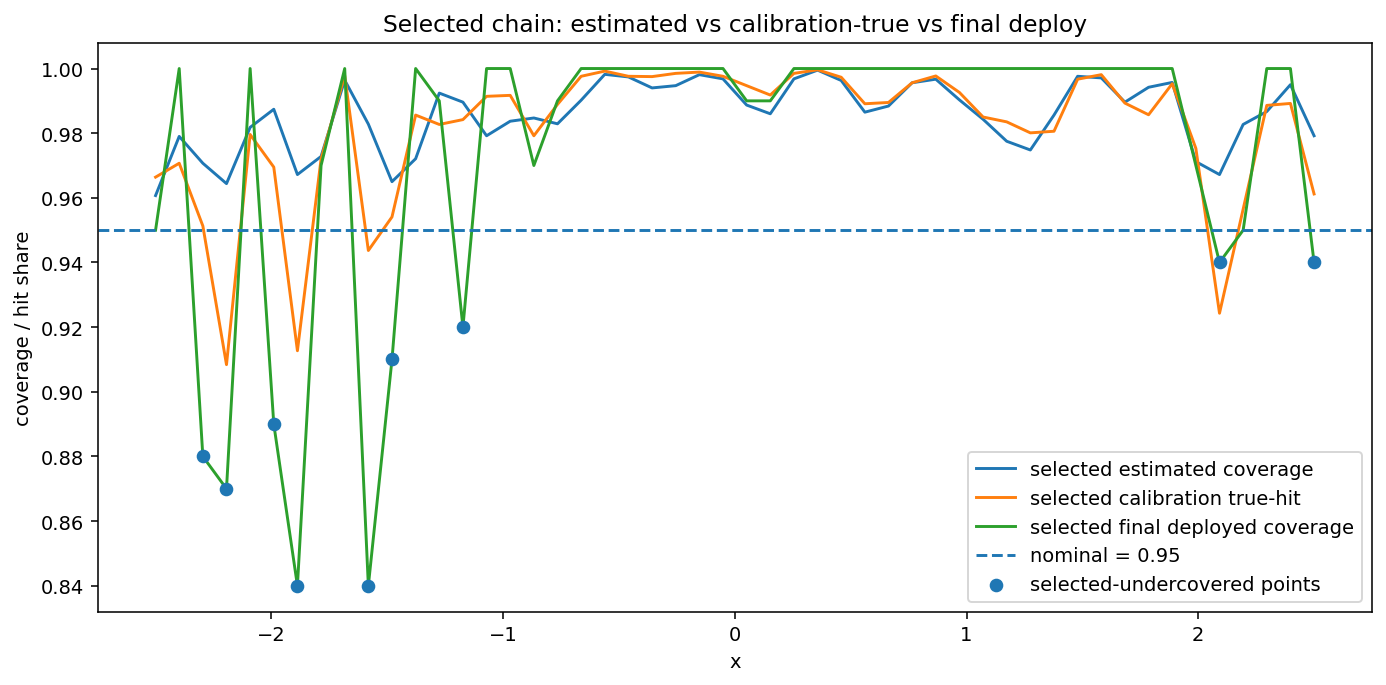

In [7]:
plt.figure(figsize=(10, 5.0))
plt.plot(x_ref, pointwise_selected_df["selected_estimated_coverage"], label="selected estimated coverage")
plt.plot(x_ref, pointwise_selected_df["selected_calib_true_hit_share"], label="selected calibration true-hit")
plt.plot(x_ref, pointwise_selected_df["selected_actual_deploy_coverage"], label="selected final deployed coverage")
plt.axhline(nominal, linestyle="--", label=f"nominal = {nominal:.2f}")
if U > 0:
    plt.scatter(
        x_ref[under_idx],
        pointwise_selected_df.loc[under_mask, "selected_actual_deploy_coverage"],
        label="selected-undercovered points",
        zorder=3,
    )
plt.xlabel("x")
plt.ylabel("coverage / hit share")
plt.title("Selected chain: estimated vs calibration-true vs final deploy")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_selected_chain_three_way.png", bbox_inches="tight")
plt.show()

## 5. Exact calibration-bank center-offset audit

This is the **exact** version of the pseudo-truth / center audit inside the saved calibration bootstrap bank.
For the selected alpha:

- compare pseudo-truth hit share vs true-f hit share inside the calibration bank
- compare mean absolute standardized offsets from the calibration interval center
- compare the same quantities under the final deployed interval

In [8]:
selected_center_offset_df = pd.DataFrame({
    "x": x_ref,
    "true_f": true_f_ref,
    "selected_calib_pseudo_hit_share": selected_calib_pseudo_cov_mat.mean(axis=0),
    "selected_calib_true_hit_share": selected_calib_true_cov_mat.mean(axis=0),
    "selected_calib_pseudo_minus_true_hit": selected_calib_pseudo_cov_mat.mean(axis=0) - selected_calib_true_cov_mat.mean(axis=0),
    "mean_abs_selected_calib_pseudo_z": selected_calib_pseudo_z_meanabs_mat.mean(axis=0),
    "mean_abs_selected_calib_true_z": selected_calib_true_z_meanabs_mat.mean(axis=0),
    "mean_abs_selected_calib_true_minus_pseudo_z": selected_calib_true_z_meanabs_mat.mean(axis=0) - selected_calib_pseudo_z_meanabs_mat.mean(axis=0),
    "mean_signed_selected_calib_pseudo_z": selected_calib_pseudo_z_signed_mat.mean(axis=0),
    "mean_signed_selected_calib_true_z": selected_calib_true_z_signed_mat.mean(axis=0),
    "selected_deploy_pseudo_hit_share": selected_deploy_pseudo_hit_mat.mean(axis=0),
    "selected_actual_deploy_coverage": pointwise_selected_actual,
    "selected_deploy_pseudo_minus_true_hit": selected_deploy_pseudo_hit_mat.mean(axis=0) - pointwise_selected_actual,
    "mean_abs_selected_deploy_pseudo_z": np.mean(np.abs(selected_deploy_pseudo_z_mat), axis=0),
    "mean_abs_selected_deploy_true_z": np.mean(np.abs(selected_deploy_true_z_mat), axis=0),
    "mean_abs_selected_deploy_true_minus_pseudo_z": np.mean(np.abs(selected_deploy_true_z_mat), axis=0) - np.mean(np.abs(selected_deploy_pseudo_z_mat), axis=0),
})
selected_center_offset_df.to_csv(OUTPUT_DIR / "03_selected_center_offset_summary.csv", index=False)

undercovered_center_offset_df = selected_center_offset_df.loc[under_mask].copy()
undercovered_center_offset_df = undercovered_center_offset_df.sort_values(["selected_actual_deploy_coverage", "x"], ascending=[True, True]).reset_index(drop=True)
undercovered_center_offset_df.to_csv(OUTPUT_DIR / "04_undercovered_selected_center_offset_summary.csv", index=False)

undercovered_center_offset_df

,x,true_f,selected_calib_pseudo_hit_share,selected_calib_true_hit_share,selected_calib_pseudo_minus_true_hit,mean_abs_selected_calib_pseudo_z,mean_abs_selected_calib_true_z,mean_abs_selected_calib_true_minus_pseudo_z,mean_signed_selected_calib_pseudo_z,mean_signed_selected_calib_true_z,selected_deploy_pseudo_hit_share,selected_actual_deploy_coverage,selected_deploy_pseudo_minus_true_hit,mean_abs_selected_deploy_pseudo_z,mean_abs_selected_deploy_true_z,mean_abs_selected_deploy_true_minus_pseudo_z
0,-1.887755,1.055191,0.9672,0.9127,0.0545,0.711487,0.919575,0.208087,0.244355,0.917911,0.92,0.84,0.08,0.785788,1.312222,0.526434
1,-1.581633,0.506969,0.9828,0.9437,0.0391,0.631122,0.851336,0.220215,-0.212641,-0.843716,0.94,0.84,0.10,0.706428,1.330908,0.624480
2,-2.193878,-0.460571,0.9644,0.9084,0.0560,0.669978,0.942972,0.272995,-0.278979,-0.942761,0.91,0.87,0.04,0.669963,1.231497,0.561535
3,-2.295918,-0.547295,0.9707,0.9513,0.0194,0.695559,0.724267,0.028708,-0.249389,-0.675082,0.95,0.88,0.07,0.659930,0.700199,0.040269
4,-1.989796,0.539654,0.9874,0.9695,0.0179,0.573601,0.792206,0.218604,0.163614,0.777095,0.97,0.89,0.08,0.600245,1.069915,0.469670
5,-1.479592,-0.262983,0.9650,0.9541,0.0109,0.696441,0.585497,-0.110944,-0.225262,-0.488412,0.93,0.91,0.02,0.709720,0.744786,0.035066
6,-1.173469,-1.351151,0.9896,0.9842,0.0054,0.612786,0.547171,-0.065615,0.155291,0.489533,0.96,0.92,0.04,0.705060,0.876383,0.171323
7,2.091837,1.045520,0.9672,0.9243,0.0429,0.695562,0.750082,0.054520,0.131000,0.692456,0.94,0.94,0.00,0.740357,0.931849,0.191492
8,2.500000,0.173318,0.9792,0.9612,0.0180,0.593190,0.701128,0.107938,0.163463,0.697603,1.00,0.94,0.06,0.535254,0.999065,0.463811


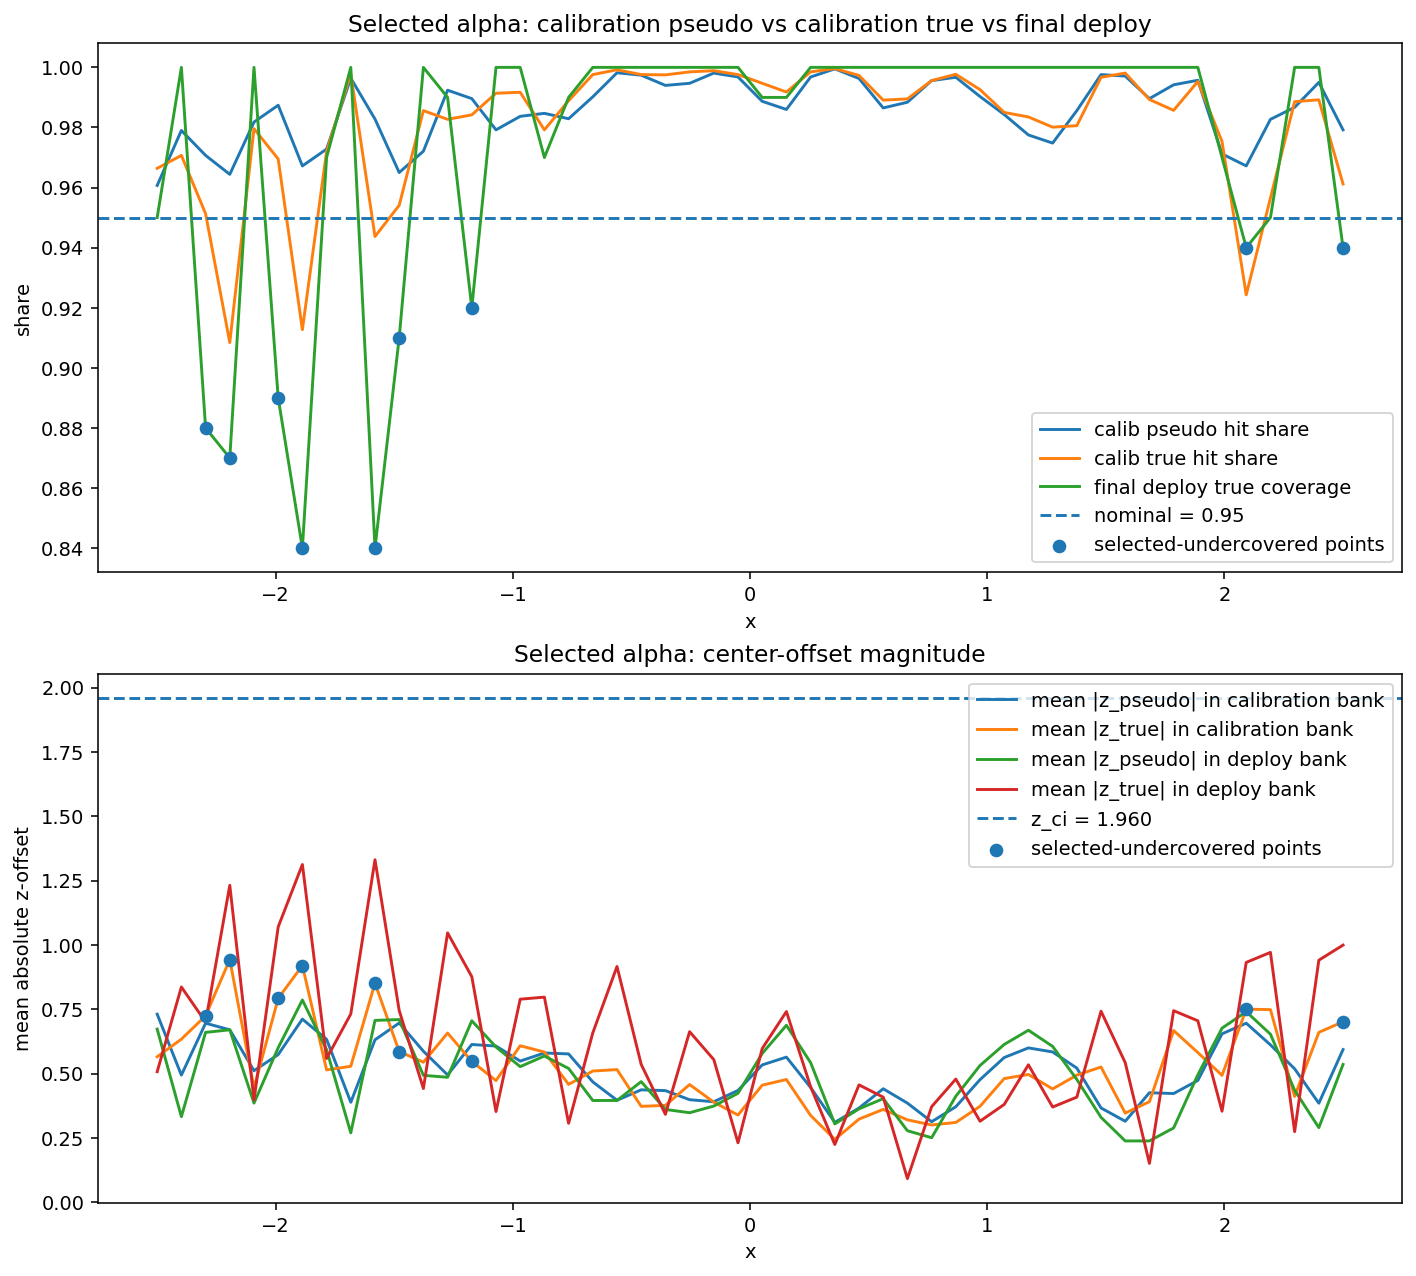

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 9.0), constrained_layout=True)

axes[0].plot(x_ref, selected_center_offset_df["selected_calib_pseudo_hit_share"], label="calib pseudo hit share")
axes[0].plot(x_ref, selected_center_offset_df["selected_calib_true_hit_share"], label="calib true hit share")
axes[0].plot(x_ref, selected_center_offset_df["selected_actual_deploy_coverage"], label="final deploy true coverage")
axes[0].axhline(nominal, linestyle="--", label=f"nominal = {nominal:.2f}")
axes[0].scatter(
    x_ref[under_idx],
    selected_center_offset_df.loc[under_mask, "selected_actual_deploy_coverage"],
    label="selected-undercovered points",
    zorder=3,
)
axes[0].set_xlabel("x")
axes[0].set_ylabel("share")
axes[0].set_title("Selected alpha: calibration pseudo vs calibration true vs final deploy")
axes[0].legend()

axes[1].plot(x_ref, selected_center_offset_df["mean_abs_selected_calib_pseudo_z"], label="mean |z_pseudo| in calibration bank")
axes[1].plot(x_ref, selected_center_offset_df["mean_abs_selected_calib_true_z"], label="mean |z_true| in calibration bank")
axes[1].plot(x_ref, selected_center_offset_df["mean_abs_selected_deploy_pseudo_z"], label="mean |z_pseudo| in deploy bank")
axes[1].plot(x_ref, selected_center_offset_df["mean_abs_selected_deploy_true_z"], label="mean |z_true| in deploy bank")
axes[1].axhline(z_ci, linestyle="--", label=f"z_ci = {z_ci:.3f}")
axes[1].scatter(
    x_ref[under_idx],
    selected_center_offset_df.loc[under_mask, "mean_abs_selected_calib_true_z"],
    label="selected-undercovered points",
    zorder=3,
)
axes[1].set_xlabel("x")
axes[1].set_ylabel("mean absolute z-offset")
axes[1].set_title("Selected alpha: center-offset magnitude")
axes[1].legend()

plt.savefig(OUTPUT_DIR / "02_selected_center_offset_audit.png", bbox_inches="tight")
plt.show()

## 6. All-alpha diagnostics on the selected-undercovered points

For the points that remain undercovered under the selected final deployed rule, inspect all alpha values for:

- estimated pseudo coverage
- calibration-bank true coverage
- final deployed true coverage
- pseudo-target bias
- deploy transfer gap
- total gap

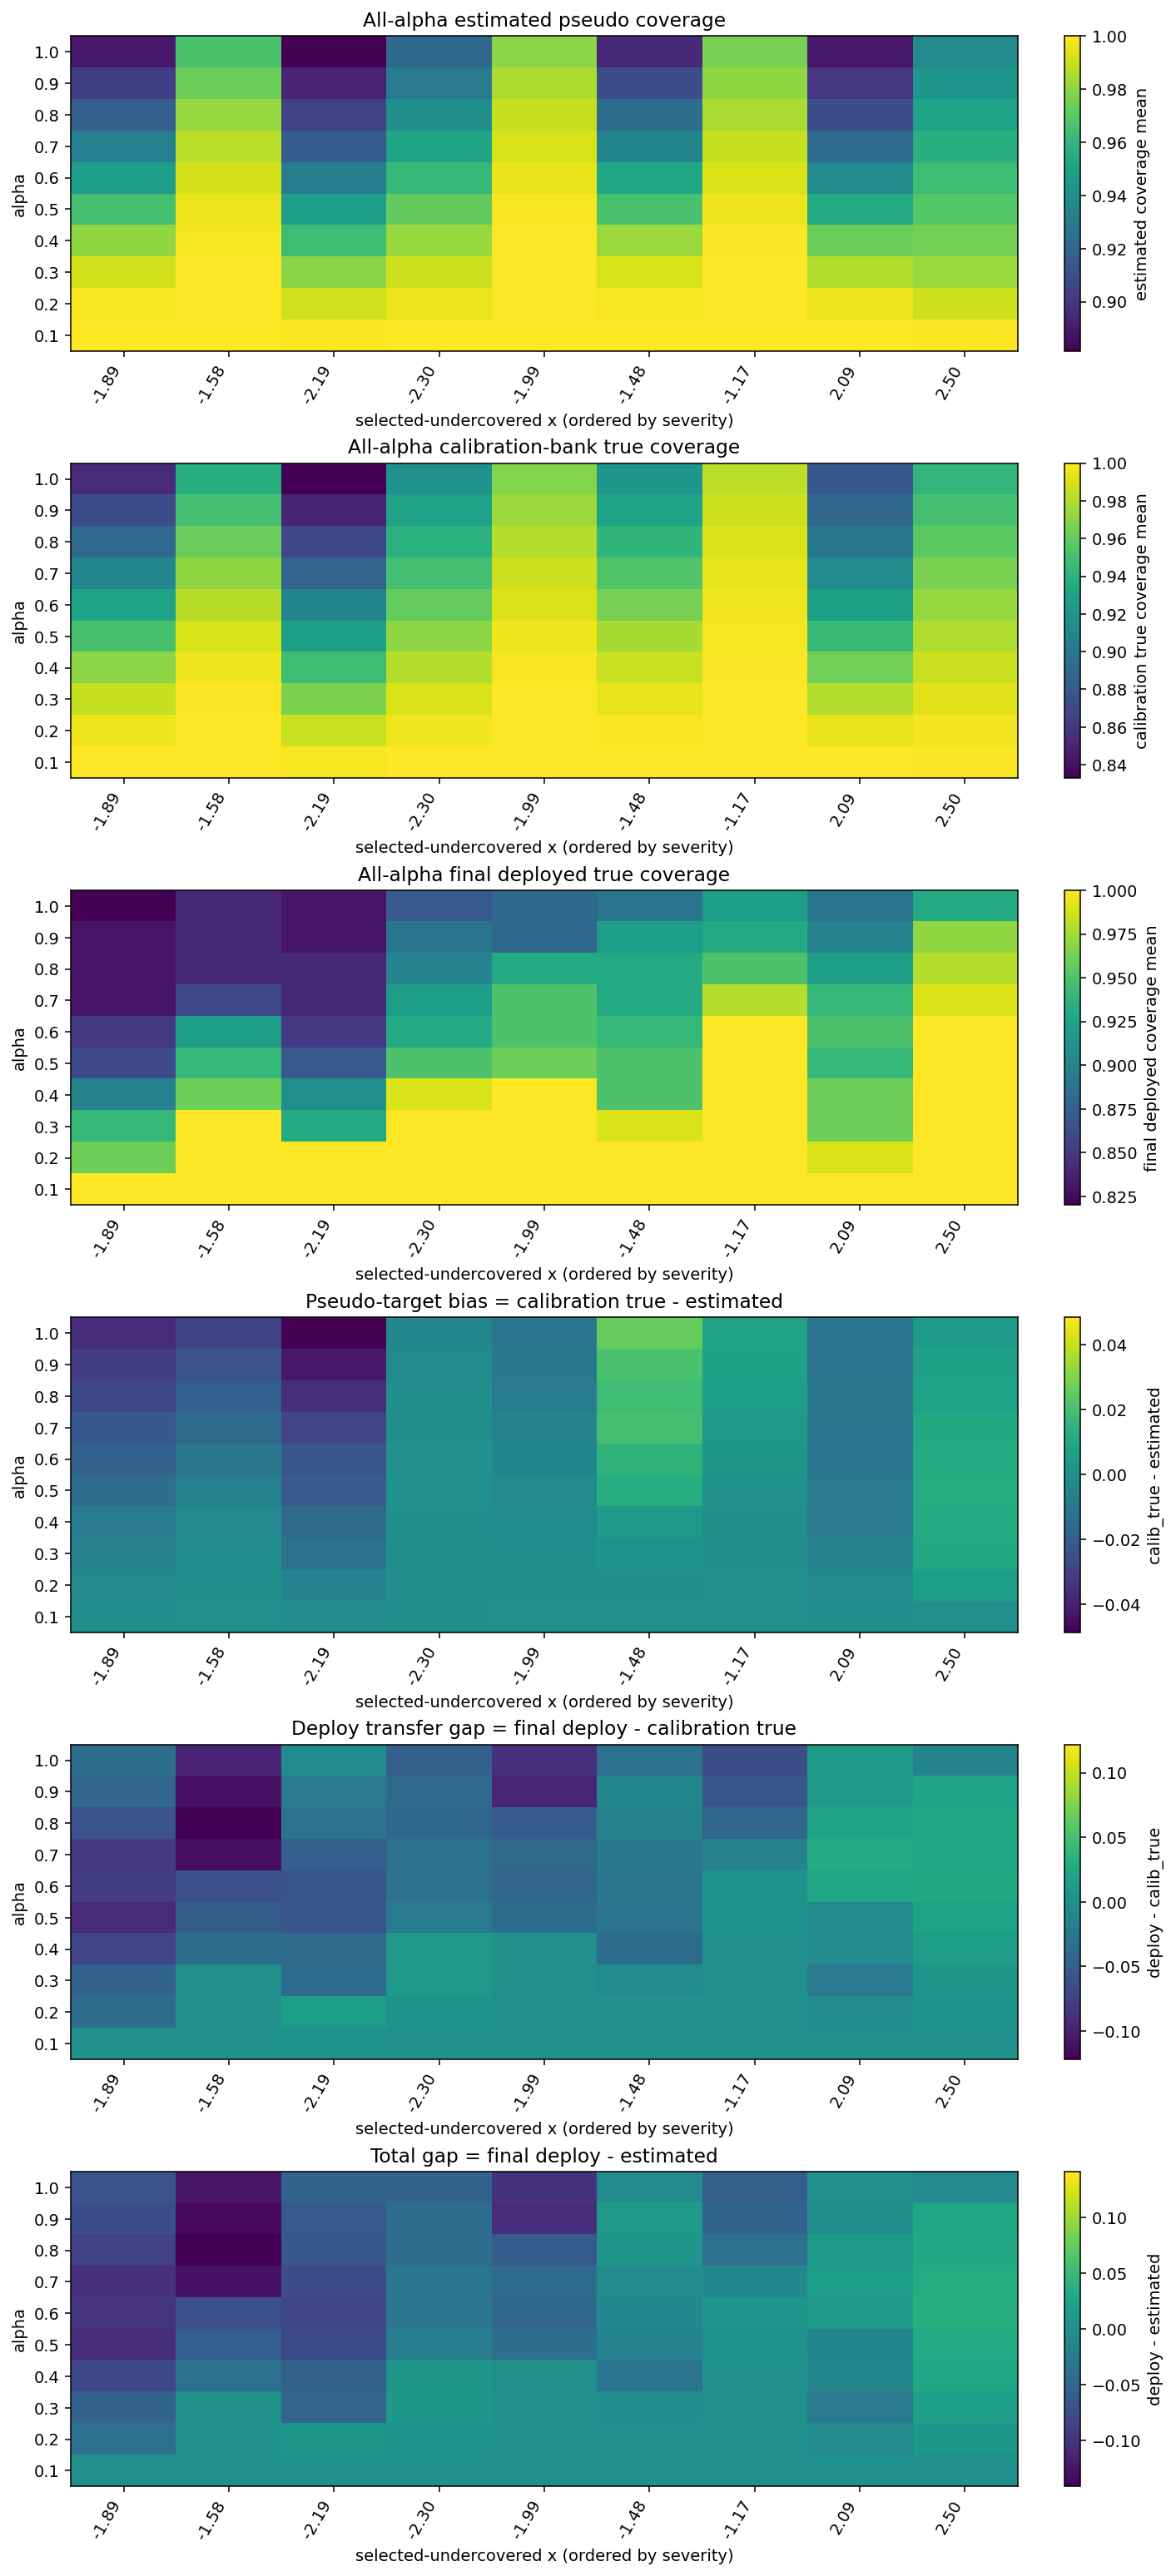

In [10]:
if U > 0:
    severity_order = np.argsort(pointwise_selected_actual[under_idx])
    under_idx_ord = under_idx[severity_order]
    under_x_ord = x_ref[under_idx_ord]

    est_under = est_cov_all_mean[under_idx_ord, :]
    calib_true_under = calib_true_cov_all_mean[under_idx_ord, :]
    deploy_under = actual_cov_all_mean[under_idx_ord, :]

    pseudo_bias_under = calib_true_under - est_under
    deploy_transfer_under = deploy_under - calib_true_under
    total_gap_under = deploy_under - est_under

    fig, axes = plt.subplots(6, 1, figsize=(max(10, 0.6 * U), 22), constrained_layout=True)

    mats = [
        (est_under, "All-alpha estimated pseudo coverage", "estimated coverage mean", None),
        (calib_true_under, "All-alpha calibration-bank true coverage", "calibration true coverage mean", None),
        (deploy_under, "All-alpha final deployed true coverage", "final deployed coverage mean", None),
        (pseudo_bias_under, "Pseudo-target bias = calibration true - estimated", "calib_true - estimated", "signed"),
        (deploy_transfer_under, "Deploy transfer gap = final deploy - calibration true", "deploy - calib_true", "signed"),
        (total_gap_under, "Total gap = final deploy - estimated", "deploy - estimated", "signed"),
    ]

    for ax, (mat, title, cbar_label, kind) in zip(axes, mats):
        if kind == "signed":
            vmax = np.max(np.abs(mat)) if mat.size else 1.0
            im = ax.imshow(mat.T, aspect="auto", origin="lower", vmin=-vmax, vmax=vmax)
        else:
            im = ax.imshow(mat.T, aspect="auto", origin="lower")
        ax.set_title(title)
        ax.set_xlabel("selected-undercovered x (ordered by severity)")
        ax.set_ylabel("alpha")
        ax.set_xticks(np.arange(U))
        ax.set_xticklabels([f"{x:.2f}" for x in under_x_ord], rotation=60, ha="right")
        ax.set_yticks(np.arange(A))
        ax.set_yticklabels([f"{a:.1f}" for a in alpha_vals_ref])
        fig.colorbar(im, ax=ax, label=cbar_label)

    plt.savefig(OUTPUT_DIR / "03_undercovered_all_alpha_sixway_heatmaps.png", bbox_inches="tight")
    plt.show()

## 7. Best-alpha comparisons: estimate vs calibration-true vs deployed-true

In [11]:
compare_rows = []
if U > 0:
    for j in under_idx:
        est_vec = est_cov_all_mean[j, :]
        calib_true_vec = calib_true_cov_all_mean[j, :]
        act_vec = actual_cov_all_mean[j, :]

        best_est_idx = int(np.argmin(np.abs(est_vec - nominal)))
        best_calib_true_idx = int(np.argmin(np.abs(calib_true_vec - nominal)))
        best_act_idx = int(np.argmin(np.abs(act_vec - nominal)))

        compare_rows.append({
            "x": float(x_ref[j]),
            "true_f": float(true_f_ref[j]),
            "selected_actual_deploy_coverage": float(pointwise_selected_actual[j]),
            "selected_estimated_coverage": float(pointwise_selected_df.loc[j, "selected_estimated_coverage"]),
            "selected_calib_true_hit_share": float(pointwise_selected_df.loc[j, "selected_calib_true_hit_share"]),
            "selected_alpha_mean": float(selected_alpha_mat[:, j].mean()),
            "selected_alpha_sd": float(selected_alpha_mat[:, j].std(ddof=1)) if R > 1 else 0.0,
            "best_alpha_by_estimated_mean": float(alpha_vals_ref[best_est_idx]),
            "best_estimated_coverage": float(est_vec[best_est_idx]),
            "best_estimated_abs_error_to_nominal": float(abs(est_vec[best_est_idx] - nominal)),
            "best_alpha_by_calib_true_mean": float(alpha_vals_ref[best_calib_true_idx]),
            "best_calib_true_coverage": float(calib_true_vec[best_calib_true_idx]),
            "best_calib_true_abs_error_to_nominal": float(abs(calib_true_vec[best_calib_true_idx] - nominal)),
            "best_alpha_by_actual_deploy_mean": float(alpha_vals_ref[best_act_idx]),
            "best_actual_deploy_coverage": float(act_vec[best_act_idx]),
            "best_actual_abs_error_to_nominal": float(abs(act_vec[best_act_idx] - nominal)),
            "best_est_vs_calib_true_match": bool(np.isclose(alpha_vals_ref[best_est_idx], alpha_vals_ref[best_calib_true_idx])),
            "best_calib_true_vs_actual_match": bool(np.isclose(alpha_vals_ref[best_calib_true_idx], alpha_vals_ref[best_act_idx])),
            "best_est_vs_actual_match": bool(np.isclose(alpha_vals_ref[best_est_idx], alpha_vals_ref[best_act_idx])),
        })

compare_df = pd.DataFrame(compare_rows)

if U > 0:
    labels = []
    tol = 0.02
    for _, row in compare_df.iterrows():
        if row["best_actual_abs_error_to_nominal"] <= tol:
            if row["best_est_vs_actual_match"]:
                lbl = "actual_support_exists_same_as_est"
            elif row["best_calib_true_vs_actual_match"]:
                lbl = "actual_support_exists_same_as_calib_true"
            else:
                lbl = "actual_support_exists_but_both_selection_stages_miss"
        else:
            lbl = "no_actual_alpha_near_nominal"
        labels.append(lbl)
    compare_df["selection_chain_label"] = labels

compare_df.to_csv(OUTPUT_DIR / "05_undercovered_best_alpha_threeway_compare.csv", index=False)
compare_df

,x,true_f,selected_actual_deploy_coverage,selected_estimated_coverage,selected_calib_true_hit_share,selected_alpha_mean,selected_alpha_sd,best_alpha_by_estimated_mean,best_estimated_coverage,best_estimated_abs_error_to_nominal,best_alpha_by_calib_true_mean,best_calib_true_coverage,best_calib_true_abs_error_to_nominal,best_alpha_by_actual_deploy_mean,best_actual_deploy_coverage,best_actual_abs_error_to_nominal,best_est_vs_calib_true_match,best_calib_true_vs_actual_match,best_est_vs_actual_match,selection_chain_label
0,-2.295918,-0.547295,0.88,0.9707,0.9513,0.832,0.253811,0.7,0.9505,0.0005,0.7,0.9502,0.0002,0.5,0.95,0.00,True,False,False,actual_support_exists_but_both_selection_stage...
1,-2.193878,-0.460571,0.87,0.9644,0.9084,0.698,0.291281,0.5,0.9475,0.0025,0.4,0.9480,0.0020,0.3,0.93,0.02,False,False,False,actual_support_exists_but_both_selection_stage...
2,-1.989796,0.539654,0.89,0.9874,0.9695,0.987,0.067652,1.0,0.9795,0.0295,1.0,0.9690,0.0190,0.6,0.95,0.00,True,False,False,actual_support_exists_but_both_selection_stage...
3,-1.887755,1.055191,0.84,0.9672,0.9127,0.755,0.249596,0.6,0.9478,0.0022,0.5,0.9514,0.0014,0.2,0.96,0.01,False,False,False,actual_support_exists_but_both_selection_stage...
4,-1.581633,0.506969,0.84,0.9828,0.9437,0.961,0.116250,1.0,0.9666,0.0166,0.9,0.9498,0.0002,0.4,0.96,0.01,False,False,False,actual_support_exists_but_both_selection_stage...
5,-1.479592,-0.262983,0.91,0.9650,0.9541,0.782,0.243036,0.6,0.9510,0.0010,0.7,0.9547,0.0047,0.4,0.95,0.00,False,False,False,actual_support_exists_but_both_selection_stage...
6,-1.173469,-1.351151,0.92,0.9896,0.9842,0.976,0.099615,1.0,0.9758,0.0258,1.0,0.9831,0.0331,0.8,0.95,0.00,True,False,False,actual_support_exists_but_both_selection_stage...
7,2.091837,1.045520,0.94,0.9672,0.9243,0.746,0.275395,0.5,0.9538,0.0038,0.5,0.9455,0.0045,0.6,0.95,0.00,True,False,False,actual_support_exists_but_both_selection_stage...
8,2.500000,0.173318,0.94,0.9792,0.9612,0.897,0.217634,0.8,0.9503,0.0003,0.9,0.9508,0.0008,1.0,0.93,0.02,False,False,False,actual_support_exists_but_both_selection_stage...


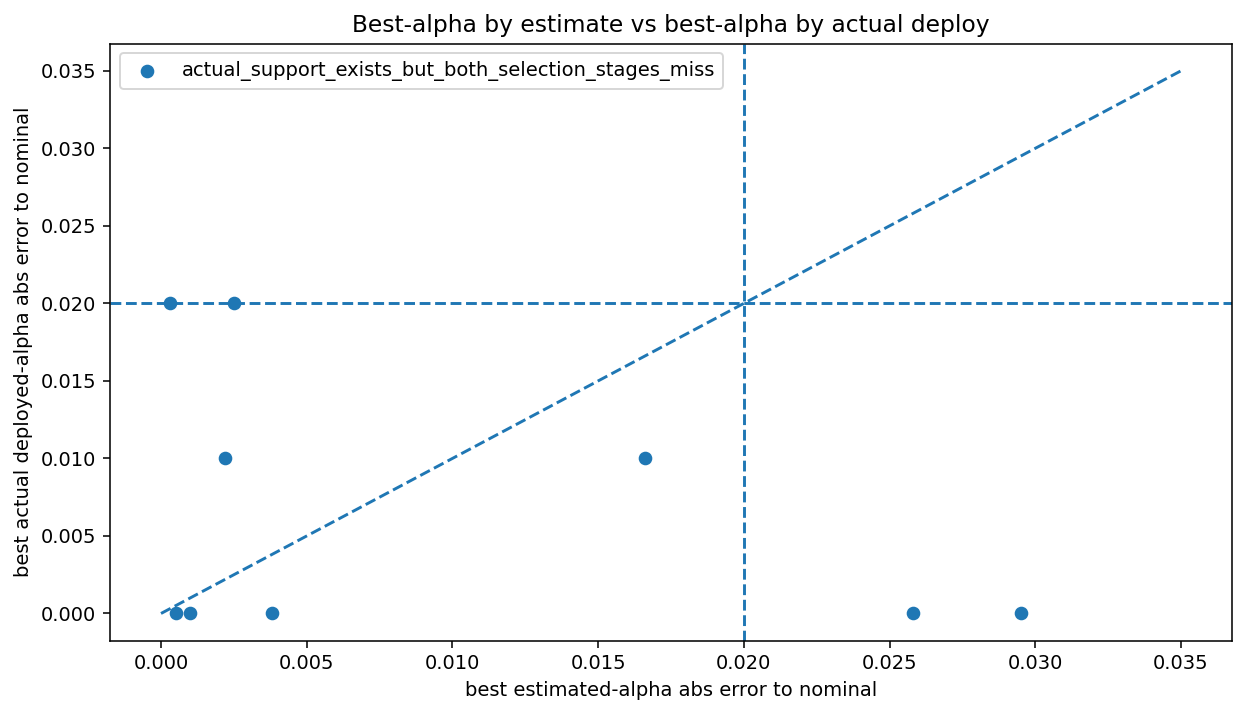

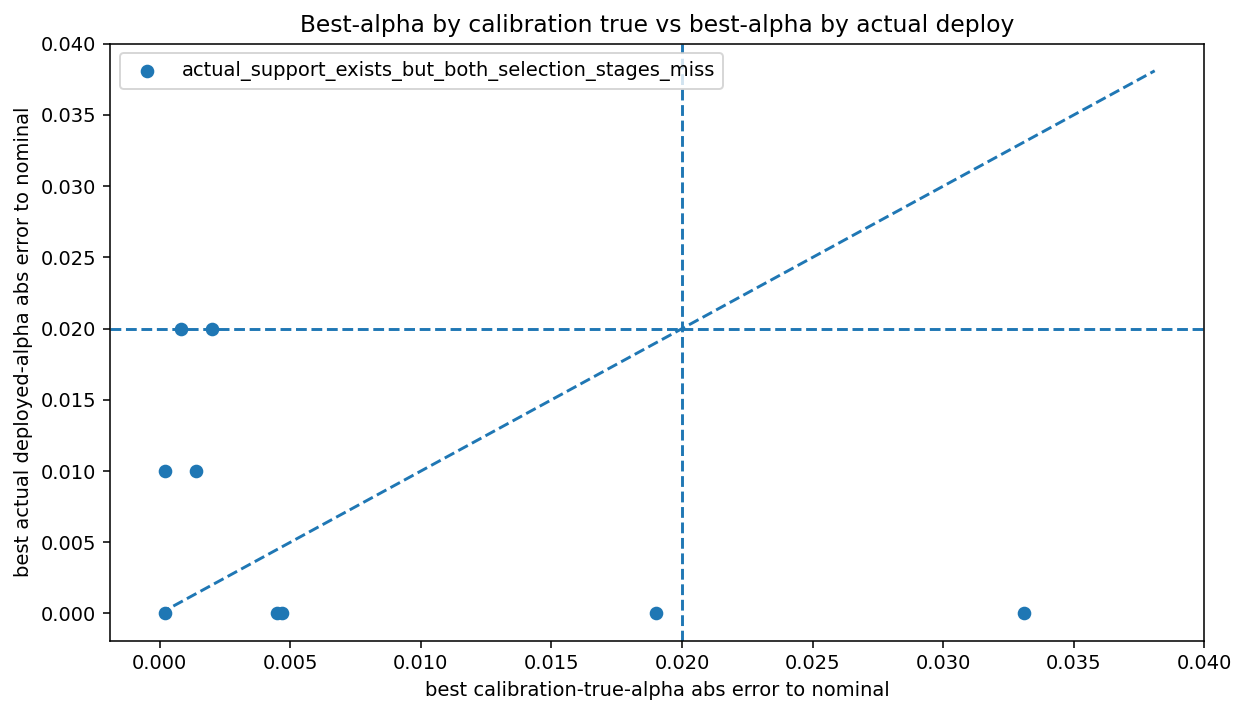

In [12]:
if U > 0:
    plt.figure(figsize=(9, 5.2))
    xvals = compare_df["best_estimated_abs_error_to_nominal"].to_numpy(dtype=float)
    yvals = compare_df["best_actual_abs_error_to_nominal"].to_numpy(dtype=float)
    for lbl in sorted(compare_df["selection_chain_label"].unique()):
        mask = compare_df["selection_chain_label"] == lbl
        plt.scatter(xvals[mask.to_numpy()], yvals[mask.to_numpy()], label=lbl)
    lim_hi = max(xvals.max(initial=0.0), yvals.max(initial=0.0), 0.03) + 0.005
    plt.plot([0.0, lim_hi], [0.0, lim_hi], linestyle="--")
    plt.axhline(0.02, linestyle="--")
    plt.axvline(0.02, linestyle="--")
    plt.xlabel("best estimated-alpha abs error to nominal")
    plt.ylabel("best actual deployed-alpha abs error to nominal")
    plt.title("Best-alpha by estimate vs best-alpha by actual deploy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "04_best_alpha_est_vs_actual_scatter.png", bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 5.2))
    xvals = compare_df["best_calib_true_abs_error_to_nominal"].to_numpy(dtype=float)
    yvals = compare_df["best_actual_abs_error_to_nominal"].to_numpy(dtype=float)
    for lbl in sorted(compare_df["selection_chain_label"].unique()):
        mask = compare_df["selection_chain_label"] == lbl
        plt.scatter(xvals[mask.to_numpy()], yvals[mask.to_numpy()], label=lbl)
    lim_hi = max(xvals.max(initial=0.0), yvals.max(initial=0.0), 0.03) + 0.005
    plt.plot([0.0, lim_hi], [0.0, lim_hi], linestyle="--")
    plt.axhline(0.02, linestyle="--")
    plt.axvline(0.02, linestyle="--")
    plt.xlabel("best calibration-true-alpha abs error to nominal")
    plt.ylabel("best actual deployed-alpha abs error to nominal")
    plt.title("Best-alpha by calibration true vs best-alpha by actual deploy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "05_best_alpha_calibtrue_vs_actual_scatter.png", bbox_inches="tight")
    plt.show()

## 8. Undercovered-point source decomposition

For each selected-undercovered point, summarize whether the failure is driven more by:

- **pseudo-target bias**
- **deploy transfer gap**
- or a mixed contribution

In [13]:
decomp_rows = []
if U > 0:
    for j in under_idx:
        est_vec = est_cov_all_mean[j, :]
        calib_true_vec = calib_true_cov_all_mean[j, :]
        deploy_vec = actual_cov_all_mean[j, :]

        pseudo_bias_vec = calib_true_vec - est_vec
        transfer_vec = deploy_vec - calib_true_vec
        total_gap_vec = deploy_vec - est_vec

        mean_abs_pseudo_bias = float(np.mean(np.abs(pseudo_bias_vec)))
        mean_abs_transfer = float(np.mean(np.abs(transfer_vec)))
        mean_abs_total = float(np.mean(np.abs(total_gap_vec)))

        if mean_abs_pseudo_bias > 1.25 * mean_abs_transfer:
            driver = "pseudo_target_bias_priority"
        elif mean_abs_transfer > 1.25 * mean_abs_pseudo_bias:
            driver = "deploy_transfer_priority"
        else:
            driver = "mixed"

        decomp_rows.append({
            "x": float(x_ref[j]),
            "selected_actual_deploy_coverage": float(pointwise_selected_actual[j]),
            "selected_estimated_coverage": float(pointwise_selected_df.loc[j, "selected_estimated_coverage"]),
            "selected_calib_true_hit_share": float(pointwise_selected_df.loc[j, "selected_calib_true_hit_share"]),
            "selected_calib_true_minus_estimated": float(pointwise_selected_df.loc[j, "selected_calib_true_minus_estimated"]),
            "selected_deploy_minus_calib_true": float(pointwise_selected_df.loc[j, "selected_deploy_minus_calib_true"]),
            "selected_deploy_minus_estimated": float(pointwise_selected_df.loc[j, "selected_deploy_minus_estimated"]),
            "mean_abs_pseudo_bias_over_all_alpha": mean_abs_pseudo_bias,
            "mean_abs_deploy_transfer_over_all_alpha": mean_abs_transfer,
            "mean_abs_total_gap_over_all_alpha": mean_abs_total,
            "dominant_driver": driver,
        })

decomp_df = pd.DataFrame(decomp_rows).sort_values(["selected_actual_deploy_coverage", "x"], ascending=[True, True]).reset_index(drop=True)
decomp_df.to_csv(OUTPUT_DIR / "06_undercovered_driver_decomposition.csv", index=False)
decomp_df

,x,selected_actual_deploy_coverage,selected_estimated_coverage,selected_calib_true_hit_share,selected_calib_true_minus_estimated,selected_deploy_minus_calib_true,selected_deploy_minus_estimated,mean_abs_pseudo_bias_over_all_alpha,mean_abs_deploy_transfer_over_all_alpha,mean_abs_total_gap_over_all_alpha,dominant_driver
0,-1.887755,0.84,0.9672,0.9127,-0.0545,-0.0727,-0.1272,0.01672,0.05391,0.07061,deploy_transfer_priority
1,-1.581633,0.84,0.9828,0.9437,-0.0391,-0.1037,-0.1428,0.01073,0.05914,0.06963,deploy_transfer_priority
2,-2.193878,0.87,0.9644,0.9084,-0.0560,-0.0384,-0.0944,0.02324,0.03065,0.05249,deploy_transfer_priority
3,-2.295918,0.88,0.9707,0.9513,-0.0194,-0.0713,-0.0907,0.00093,0.02308,0.02355,deploy_transfer_priority
4,-1.989796,0.89,0.9874,0.9695,-0.0179,-0.0795,-0.0974,0.00430,0.03529,0.03925,deploy_transfer_priority
5,-1.479592,0.91,0.9650,0.9541,-0.0109,-0.0441,-0.0550,0.01159,0.01732,0.00899,deploy_transfer_priority
6,-1.173469,0.92,0.9896,0.9842,-0.0054,-0.0642,-0.0696,0.00287,0.01825,0.01608,deploy_transfer_priority
7,2.091837,0.94,0.9672,0.9243,-0.0429,0.0157,-0.0272,0.00772,0.01270,0.01004,deploy_transfer_priority
8,2.500000,0.94,0.9792,0.9612,-0.0180,-0.0212,-0.0392,0.00806,0.01475,0.02183,deploy_transfer_priority


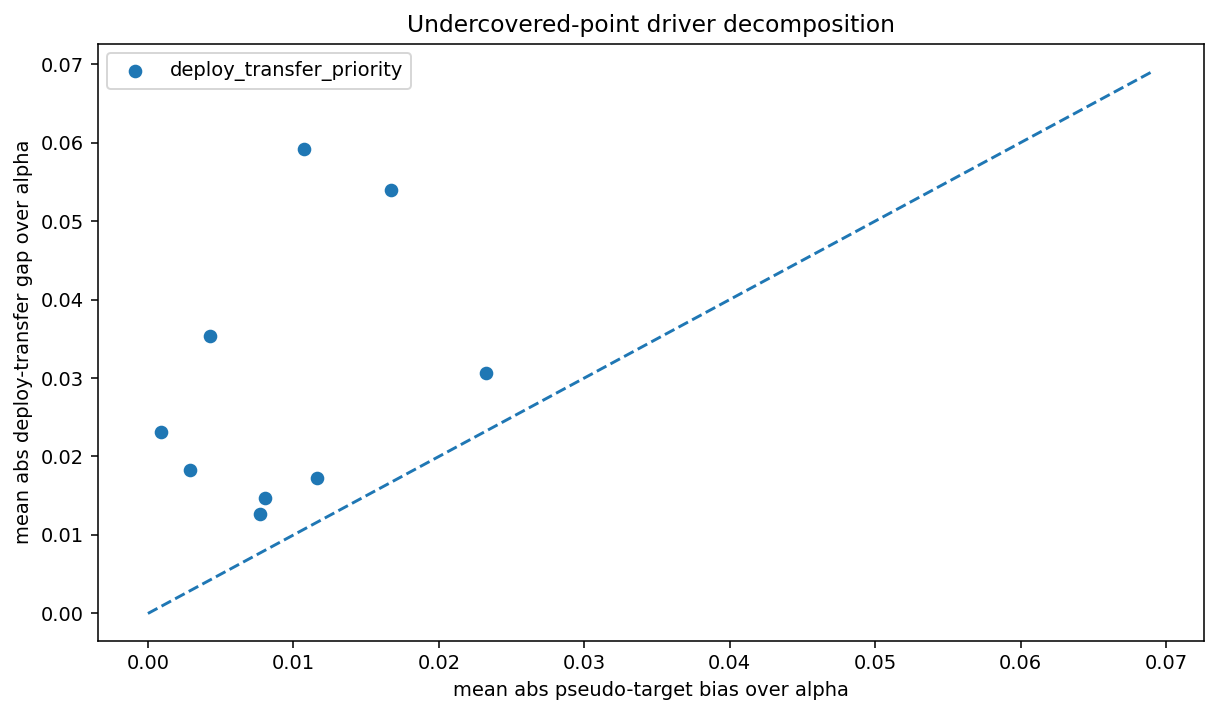

In [14]:
if U > 0:
    plt.figure(figsize=(8.8, 5.2))
    xvals = decomp_df["mean_abs_pseudo_bias_over_all_alpha"].to_numpy(dtype=float)
    yvals = decomp_df["mean_abs_deploy_transfer_over_all_alpha"].to_numpy(dtype=float)
    for lbl in sorted(decomp_df["dominant_driver"].unique()):
        mask = decomp_df["dominant_driver"] == lbl
        plt.scatter(xvals[mask.to_numpy()], yvals[mask.to_numpy()], label=lbl)
    lim_hi = max(xvals.max(initial=0.0), yvals.max(initial=0.0)) + 0.01
    plt.plot([0.0, lim_hi], [0.0, lim_hi], linestyle="--")
    plt.xlabel("mean abs pseudo-target bias over alpha")
    plt.ylabel("mean abs deploy-transfer gap over alpha")
    plt.title("Undercovered-point driver decomposition")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "06_driver_decomposition_scatter.png", bbox_inches="tight")
    plt.show()

## 9. Long-format helper table for filtering outside the notebook

In [15]:
long_rows = []
if U > 0:
    for j in under_idx:
        for ai, alpha in enumerate(alpha_vals_ref):
            pseudo_z_here = calib_pseudo_z_tensor[:, j, ai, :].reshape(-1)
            true_z_here = calib_true_z_tensor[:, j, ai, :].reshape(-1)
            true_hit_boot_here = calib_true_hit_boot_tensor[:, j, ai, :].reshape(-1)
            long_rows.append({
                "x": float(x_ref[j]),
                "true_f": float(true_f_ref[j]),
                "alpha": float(alpha),
                "selected_actual_deploy_coverage": float(pointwise_selected_actual[j]),
                "selected_estimated_coverage": float(pointwise_selected_df.loc[j, "selected_estimated_coverage"]),
                "estimated_coverage_mean": float(est_cov_all_mean[j, ai]),
                "calibration_pseudo_hit_mean": float(calib_pseudo_cov_all_mean[j, ai]),
                "calibration_true_hit_mean": float(calib_true_cov_all_mean[j, ai]),
                "final_deployed_coverage_mean": float(actual_cov_all_mean[j, ai]),
                "pseudo_target_bias": float(calib_true_cov_all_mean[j, ai] - est_cov_all_mean[j, ai]),
                "deploy_transfer_gap": float(actual_cov_all_mean[j, ai] - calib_true_cov_all_mean[j, ai]),
                "total_gap": float(actual_cov_all_mean[j, ai] - est_cov_all_mean[j, ai]),
                "mean_abs_calib_pseudo_z": float(np.mean(np.abs(pseudo_z_here))),
                "mean_abs_calib_true_z": float(np.mean(np.abs(true_z_here))),
                "mean_abs_calib_true_minus_pseudo_z": float(np.mean(np.abs(true_z_here)) - np.mean(np.abs(pseudo_z_here))),
                "calib_true_hit_boot_sd": float(np.std(true_hit_boot_here, ddof=1)),
                "estimated_abs_error_to_nominal": float(abs(est_cov_all_mean[j, ai] - nominal)),
                "calib_true_abs_error_to_nominal": float(abs(calib_true_cov_all_mean[j, ai] - nominal)),
                "deploy_abs_error_to_nominal": float(abs(actual_cov_all_mean[j, ai] - nominal)),
            })
undercovered_long_df = pd.DataFrame(long_rows)
undercovered_long_df.to_csv(OUTPUT_DIR / "07_undercovered_all_alpha_long.csv", index=False)

undercovered_long_df.head() if U > 0 else None

,x,true_f,alpha,selected_actual_deploy_coverage,selected_estimated_coverage,estimated_coverage_mean,calibration_pseudo_hit_mean,calibration_true_hit_mean,final_deployed_coverage_mean,pseudo_target_bias,deploy_transfer_gap,total_gap,mean_abs_calib_pseudo_z,mean_abs_calib_true_z,mean_abs_calib_true_minus_pseudo_z,calib_true_hit_boot_sd,estimated_abs_error_to_nominal,calib_true_abs_error_to_nominal,deploy_abs_error_to_nominal
0,-2.295918,-0.547295,0.1,0.88,0.9707,1.0000,1.0000,0.9999,1.00,-0.0001,0.0001,0.0000,0.295429,0.300376,0.004947,0.010000,0.0500,0.0499,0.05
1,-2.295918,-0.547295,0.2,0.88,0.9707,0.9967,0.9967,0.9962,1.00,-0.0005,0.0038,0.0033,0.399955,0.406385,0.006430,0.061530,0.0467,0.0462,0.05
2,-2.295918,-0.547295,0.3,0.88,0.9707,0.9910,0.9910,0.9903,1.00,-0.0007,0.0097,0.0090,0.478122,0.485569,0.007447,0.098015,0.0410,0.0403,0.05
3,-2.295918,-0.547295,0.4,0.88,0.9707,0.9816,0.9816,0.9814,0.99,-0.0002,0.0086,0.0084,0.543410,0.551666,0.008256,0.135114,0.0316,0.0314,0.04
4,-2.295918,-0.547295,0.5,0.88,0.9707,0.9715,0.9715,0.9719,0.95,0.0004,-0.0219,-0.0215,0.600580,0.609535,0.008955,0.165267,0.0215,0.0219,0.00


## 10. Quick text summary

In [16]:
print("==== COMPREHENSIVE DIAGNOSTIC SUMMARY ====")
for k, v in {**summary, **recon_summary}.items():
    print(f"{k}: {v}")

print()
print(f"Saved outputs to: {OUTPUT_DIR}")

print("\nMain tables:")
for name in [
    "00_overall_summary.csv",
    "01_pointwise_selected_chain_summary.csv",
    "02_undercovered_selected_chain_summary.csv",
    "03_selected_center_offset_summary.csv",
    "04_undercovered_selected_center_offset_summary.csv",
    "05_undercovered_best_alpha_threeway_compare.csv",
    "06_undercovered_driver_decomposition.csv",
    "07_undercovered_all_alpha_long.csv",
]:
    print(" ", OUTPUT_DIR / name)

if U > 0:
    print("\nUndercovered points:", U)
    worst = undercovered_selected_df.iloc[0]
    print(f"Worst selected-undercovered x = {worst['x']:.6f}")
    print(f" selected estimated coverage     = {worst['selected_estimated_coverage']:.6f}")
    print(f" selected calibration true-hit   = {worst['selected_calib_true_hit_share']:.6f}")
    print(f" selected final deployed coverage= {worst['selected_actual_deploy_coverage']:.6f}")

    print("\nSelection-chain label counts:")
    print(compare_df["selection_chain_label"].value_counts(dropna=False))

    print("\nDriver label counts:")
    print(decomp_df["dominant_driver"].value_counts(dropna=False))

==== COMPREHENSIVE DIAGNOSTIC SUMMARY ====
R: 100
J: 50
A: 10
B: 100
rep_id_min: 0
rep_id_max: 99
nominal: 0.95
undercovered_selected_points: 9
recon_all_alpha_curve_match: True
recon_all_mu_match: True
recon_all_std_match: True
recon_all_lower_match: True
recon_all_upper_match: True
recon_all_est_match_csv_vs_calib_bank: True
recon_all_hit_match: True

Saved outputs to: C:\Users\yangy\26 spring\with reference\familyfix\diag_results\comprehensive_diagnostics

Main tables:
  C:\Users\yangy\26 spring\with reference\familyfix\diag_results\comprehensive_diagnostics\00_overall_summary.csv
  C:\Users\yangy\26 spring\with reference\familyfix\diag_results\comprehensive_diagnostics\01_pointwise_selected_chain_summary.csv
  C:\Users\yangy\26 spring\with reference\familyfix\diag_results\comprehensive_diagnostics\02_undercovered_selected_chain_summary.csv
  C:\Users\yangy\26 spring\with reference\familyfix\diag_results\comprehensive_diagnostics\03_selected_center_offset_summary.csv
  C:\Users\yang